<a href="https://colab.research.google.com/github/lavanyan1105-afk/Brain-Tumor-/blob/main/Mobilenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow scikit-learn xgboost

In [3]:
import os
import numpy as np
import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

In [4]:
data_dir = "/content/drive/MyDrive/Brain_Tumer"

In [5]:
IMG_SIZE = 224

images = []
labels = []
all_true_class_names = [] # To store the actual class names (e.g., 'meningioma_tumor')

if not os.path.isdir(data_dir):
    print(f"Error: data_dir '{data_dir}' is not a valid directory.")
else:
    # First level: 'Testing', 'Training'
    top_level_folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]

    if not top_level_folders:
        print(f"Warning: No top-level folders (e.g., 'Testing', 'Training') found in '{data_dir}'.")
    else:
        # Loop through 'Testing' and 'Training' folders
        for top_folder in top_level_folders:
            top_folder_path = os.path.join(data_dir, top_folder)

            # Second level: 'meningioma_tumor', 'glioma_tumor', etc. (actual classes)
            class_subfolders = [f for f in os.listdir(top_folder_path) if os.path.isdir(os.path.join(top_folder_path, f))]

            if not class_subfolders:
                print(f"Warning: No class subfolders found in '{top_folder_path}'. Skipping.")
                continue

            for class_name in class_subfolders:
                # Assign a unique label index for each actual class name
                if class_name not in all_true_class_names:
                    all_true_class_names.append(class_name)

                label_idx = all_true_class_names.index(class_name)

                class_path = os.path.join(top_folder_path, class_name)

                # Third level: actual image files
                image_files = [
                    img_name for img_name in os.listdir(class_path)
                    if os.path.isfile(os.path.join(class_path, img_name)) and
                       img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))
                ]

                if not image_files:
                    print(f"Warning: No image files found in '{class_path}'. Skipping.")
                    continue

                for img_name in tqdm(image_files, desc=f"Loading images from {top_folder}/{class_name}"):
                    img_path = os.path.join(class_path, img_name)

                    img = cv2.imread(img_path)

                    if img is None:
                        print(f"Warning: Could not read image '{img_path}'. Skipping.")
                        continue

                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    images.append(img)
                    labels.append(label_idx)

if images:
    images = np.array(images)
    labels = np.array(labels)

    print("Total images:", len(images))
    print("Classes:", all_true_class_names)
else:
    print("No images were loaded.")

Loading images from Training/glioma_tumor: 100%|██████████| 826/826 [00:25<00:00, 32.04it/s] 


Total images: 3264
Classes: ['meningioma_tumor', 'pituitary_tumor', 'no_tumor', 'glioma_tumor']


In [6]:
from tensorflow.keras.applications.mobilenet import preprocess_input
images = preprocess_input(images)

In [7]:
mobilenet = MobileNet(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3),
    pooling="avg"
)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
features = mobilenet.predict(images)

print("Feature shape:", features.shape)

102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step
Feature shape: (3264, 1024)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [10]:
svm = SVC(kernel="rbf")

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred))

SVM Accuracy: 0.8958652373660031


In [11]:
svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, pred_linear))

Linear SVM Accuracy: 0.9081163859111792


TRAINING XGBOOST

In [12]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8836140888208269


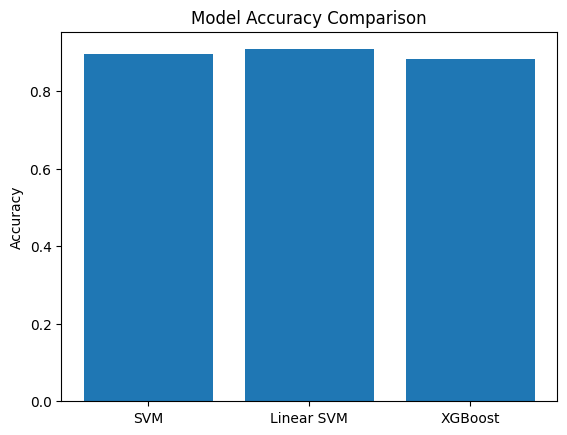

In [13]:
import matplotlib.pyplot as plt

models = ["SVM", "Linear SVM", "XGBoost"]
scores = [
    accuracy_score(y_test, pred),
    accuracy_score(y_test, pred_linear),
    accuracy_score(y_test, xgb_pred)
]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [14]:
train_sizes = [0.2, 0.4, 0.6, 0.8]

svm_rbf_scores = []
svm_linear_scores = []
xgb_scores = []

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from xgboost import XGBClassifier

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

    # Reduce training data size
    train_limit = int(len(X_train) * size)

    X_train_small = X_train[:train_limit]
    y_train_small = y_train[:train_limit]

    # SVM RBF
    svm_rbf = SVC(kernel="rbf")
    svm_rbf.fit(X_train_small, y_train_small)

    pred_rbf = svm_rbf.predict(X_test)
    svm_rbf_scores.append(accuracy_score(y_test, pred_rbf))

    # SVM Linear
    svm_linear = SVC(kernel="linear")
    svm_linear.fit(X_train_small, y_train_small)

    pred_linear = svm_linear.predict(X_test)
    svm_linear_scores.append(accuracy_score(y_test, pred_linear))

    # XGBoost
    xgb = XGBClassifier()
    xgb.fit(X_train_small, y_train_small)

    pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, pred_xgb))

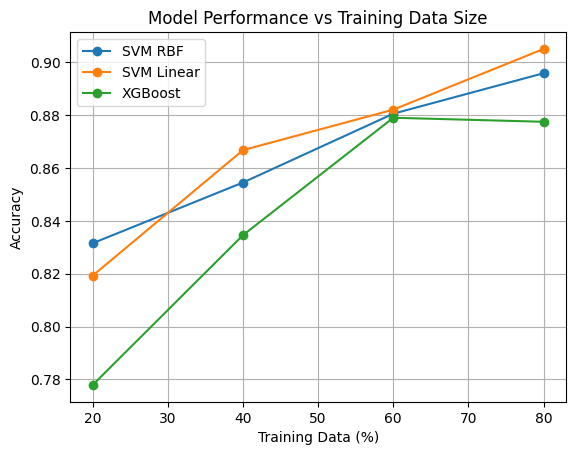

In [16]:
import matplotlib.pyplot as plt

train_percent = [20, 40, 60, 80]

plt.plot(train_percent, svm_rbf_scores, marker='o', label="SVM RBF")
plt.plot(train_percent, svm_linear_scores, marker='o', label="SVM Linear")
plt.plot(train_percent, xgb_scores, marker='o', label="XGBoost")

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy")
plt.title("Model Performance vs Training Data Size")
plt.legend()
plt.grid(True)

plt.show()